## Лабораторна робота 4. **REGRESSION** 📈

# Опис вибірки "Motorbike Ambulance Calls"


Аварії за участю мотоциклів та відповідні виклики швидкої допомоги сильно залежать від екологічних та сезонних умов, таких як погодні умови, опади, день тижня, сезон, година дня тощо. Дані збирались протягом двох років щогодини та потім співвідносилися з відповідною погодою та сезонністю.

Основні характеристики вибірки `motorbike_ambulance_calls.csv`:

              - index: record index
              - date : date
              - season : season (1:springer, 2:summer, 3:fall, 4:winter)
              - yr : year (0: 2011, 1:2012)
              - mnth : month ( 1 to 12)
              - hr : hour (0 to 23)
              - holiday : whether day is holiday or not
              - weekday : day of the week
              - workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
              -  weathersit :
                      - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
                      - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
                      - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
                      - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
              - temp : Normalized temperature in Celsius. The values are divided to 41 (max)
              - atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
              - hum: Normalized humidity. The values are divided to 100 (max)
              - windspeed: Normalized wind speed. The values are divided to 67 (max)
              - cnt: count of total ambulance calls

## Імпорт необхідних бібліотек та завантаження даних

**Завдання 1** підготовка даних до опрацювання

1. завантажте вибірку `motorbike_ambulance_calls.csv`;   
2. підключіть необхідні бібліотеки;  
3. вивести основну статистичну інформацію по числовим змінним;  
4. окремо вивести максимальні та мінімальні значення по всім змінним;  
5. вивести розмірність датасету;

In [831]:
import pandas as pd
import numpy as np
import scipy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [832]:
def get_data(data_path: str):
  data = pd.read_csv(data_path)
  return data

In [833]:
df = get_data(data_path="./datasets/motorbike_ambulance_calls.csv")

In [834]:
df.describe()

,index,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,189.463088
std,5017.0295,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,181.387599
min,1.0000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,40.000000
50%,8690.0000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000
75%,13034.5000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,281.000000
max,17379.0000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,977.000000


In [835]:
df.max()

index          17379
date          9/9/12
season        winter
yr                 1
mnth              12
hr                23
holiday            1
weekday            6
workingday         1
weathersit         4
temp             1.0
atemp            1.0
hum              1.0
windspeed     0.8507
cnt              977
dtype: object

In [836]:
df.min()

index              1
date          1/1/11
season        autumn
yr                 0
mnth               1
hr                 0
holiday            0
weekday            0
workingday         0
weathersit         1
temp            0.02
atemp            0.0
hum              0.0
windspeed        0.0
cnt                1
dtype: object

In [837]:
df.shape

(17379, 15)

**Завдання 2** перевірити типи даних та перевірте кількість даних по кожній змінній.

In [838]:
df.dtypes

index           int64
date           object
season         object
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
cnt             int64
dtype: object

In [839]:
df.count()

index         17379
date          17379
season        17379
yr            17379
mnth          17379
hr            17379
holiday       17379
weekday       17379
workingday    17379
weathersit    17379
temp          17379
atemp         17379
hum           17379
windspeed     17379
cnt           17379
dtype: int64

**Завдання 3** пепевірте всі змінні на наявність пропусків.

In [840]:
missing_values = df.isnull().sum()
missing_values

index         0
date          0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

**Висновки з 1-3 завдання (детальні)**



1.   Dataset has no missing values
2.   Most datatypes is numerical
3.   Max count of call = 975
4.   Mean count of calls 189.463088


**Завдання 4** перетворіть змінну `date` в **date type**. Визначте часові межі датасету.

In [841]:
def tranform_date(df: pd.DataFrame, date_col_name: str):
    df[date_col_name] = pd.to_datetime(df[date_col_name], errors='coerce') 
    return df

In [842]:
df = tranform_date(df, 'date')

C:\Users\User\AppData\Local\Temp\ipykernel_22184\1291372656.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col_name] = pd.to_datetime(df[date_col_name], errors='coerce')


In [843]:
def get_time_limits(df: pd.DataFrame, date_col_name: str):
    first_day = df[date_col_name].min()
    last_day = df[date_col_name].max()
    print(f"First day of dataset - {first_day}.\nLast day of dataset - {last_day}")

In [844]:
get_time_limits(df, 'date')

First day of dataset - 2011-01-01 00:00:00.
Last day of dataset - 2012-12-31 00:00:00


The functions convert the 'date' column to datetime format.

#Аналіз категоріальних змінних

**Завдання 5** виділити категоріальні змінні в окремий датасет







In [845]:
df_categorical = df[["season", "holiday", "weekday", "workingday", "weathersit"]].copy()
df_categorical

,season,holiday,weekday,workingday,weathersit
0,spring,0,6,0,1
1,spring,0,6,0,1
2,spring,0,6,0,1
3,spring,0,6,0,1
4,spring,0,6,0,1
...,...,...,...,...,...
17374,spring,0,1,1,2
17375,spring,0,1,1,2
17376,spring,0,1,1,1
17377,spring,0,1,1,1


**Завдання 6** перетворіть змінну `season` в числову шкалу.

In [846]:
def encode_season(df: pd.DataFrame):
  df["season"] = df["season"].astype("category").cat.codes
  return df
  
df_categorical = encode_season(df_categorical)


In [847]:
df_categorical["season"].unique()

array([1, 2, 0, 3], dtype=int8)

**Завдання 7** побудувати графіки `countplot` по всім категоріальним змінним

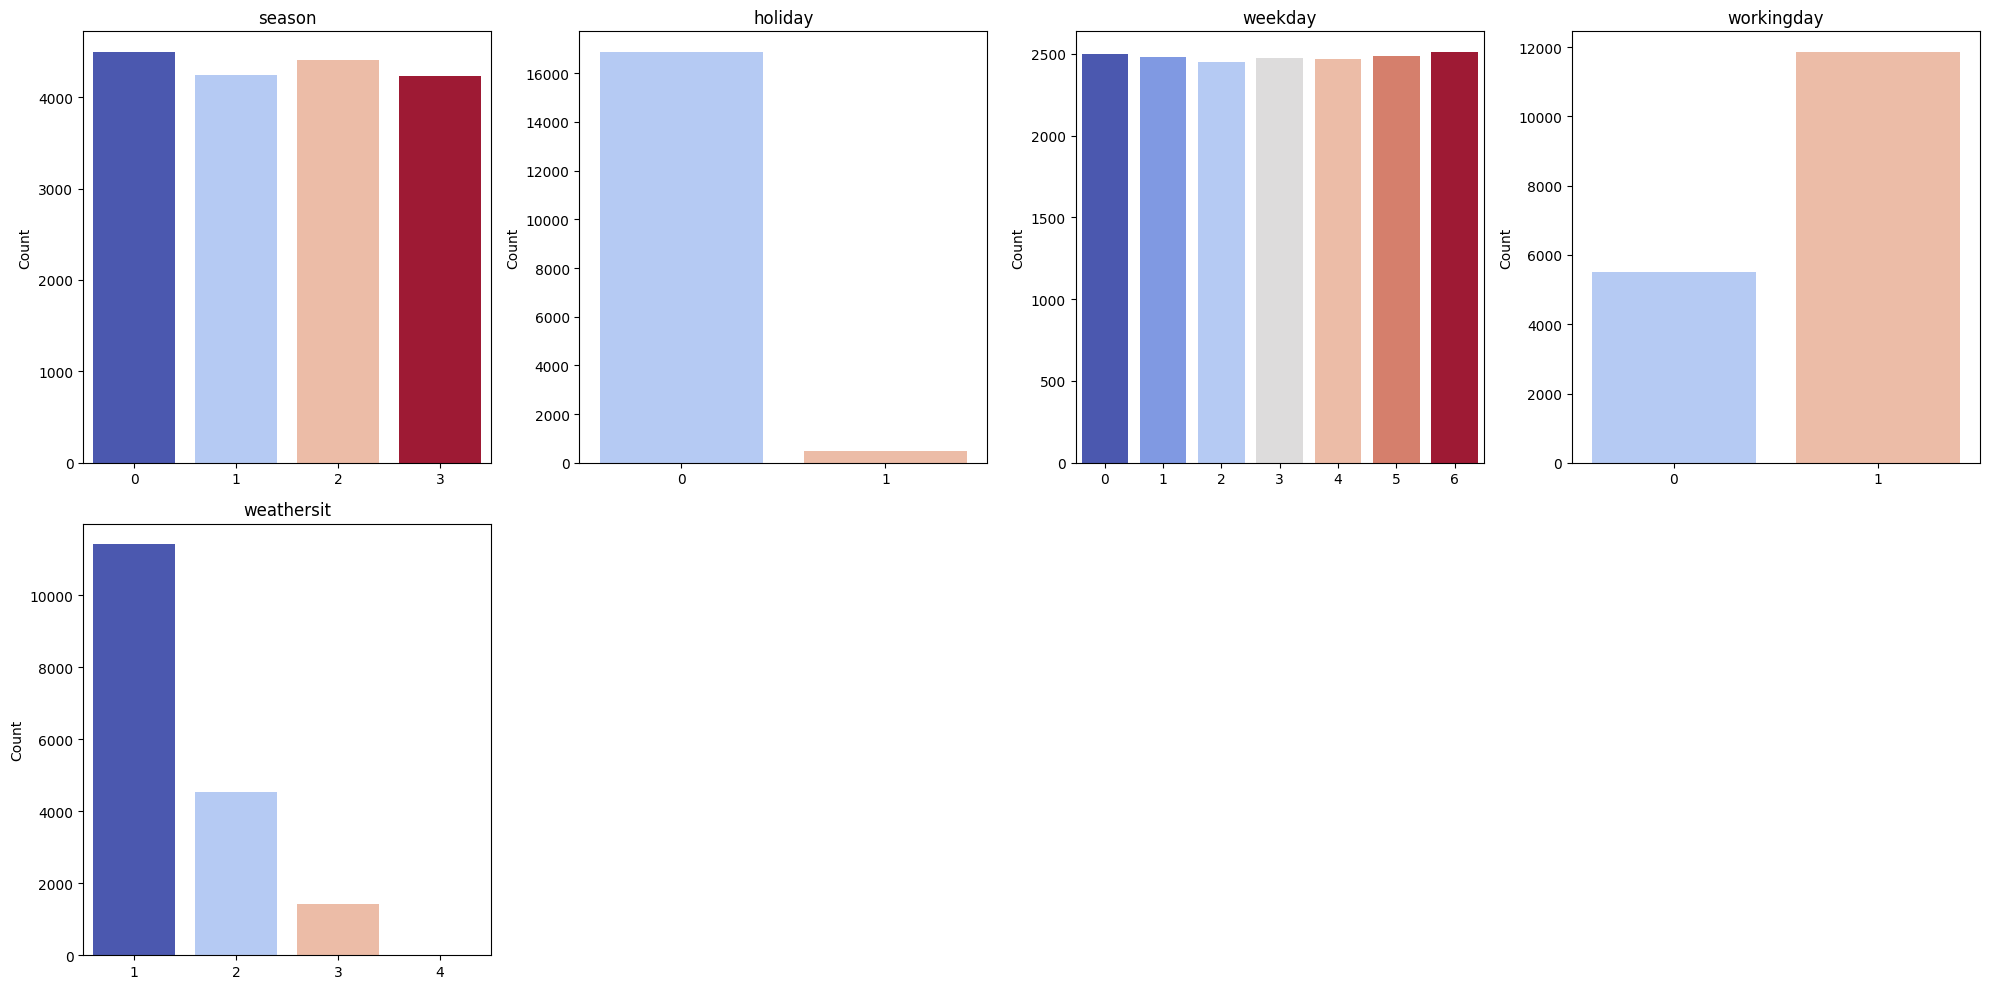

In [848]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))

for variable, subplot in zip(df_categorical.columns, ax.flatten()):
    sns.countplot(x=variable, data=df_categorical, ax=subplot, palette="coolwarm", hue=variable, legend=False)
    subplot.set_title(variable)
    subplot.set_xlabel("")
    subplot.set_ylabel("Count")
    subplot.tick_params(axis='x')

for extra_subplot in ax.flatten()[len(df_categorical.columns):]:
    fig.delaxes(extra_subplot)

plt.tight_layout()
plt.show()


**Висновки з 5-7 завдання (детальні)**

  
1.   The categorical variables like: season, holiday, weekday, workingday, and weathersit were isolated for convinience.
2.   The season variable was encoded into numerical values.
3.   Visualizations using count plots.

#Аналіз числових змінних

**Завдання 8** виділити числові змінні в окремий датасет

In [849]:
data_numerical = df[["hum", "windspeed", "cnt", "weekday"]].copy()

In [850]:
data_numerical

,hum,windspeed,cnt,weekday
0,0.81,0.0000,16,6
1,0.80,0.0000,40,6
2,0.80,0.0000,32,6
3,0.75,0.0000,13,6
4,0.75,0.0000,1,6
...,...,...,...,...
17374,0.60,0.1642,119,1
17375,0.60,0.1642,89,1
17376,0.60,0.1642,90,1
17377,0.56,0.1343,61,1


**Завдання 9** побудуйте гістограми розподілу по всім числовим змінним

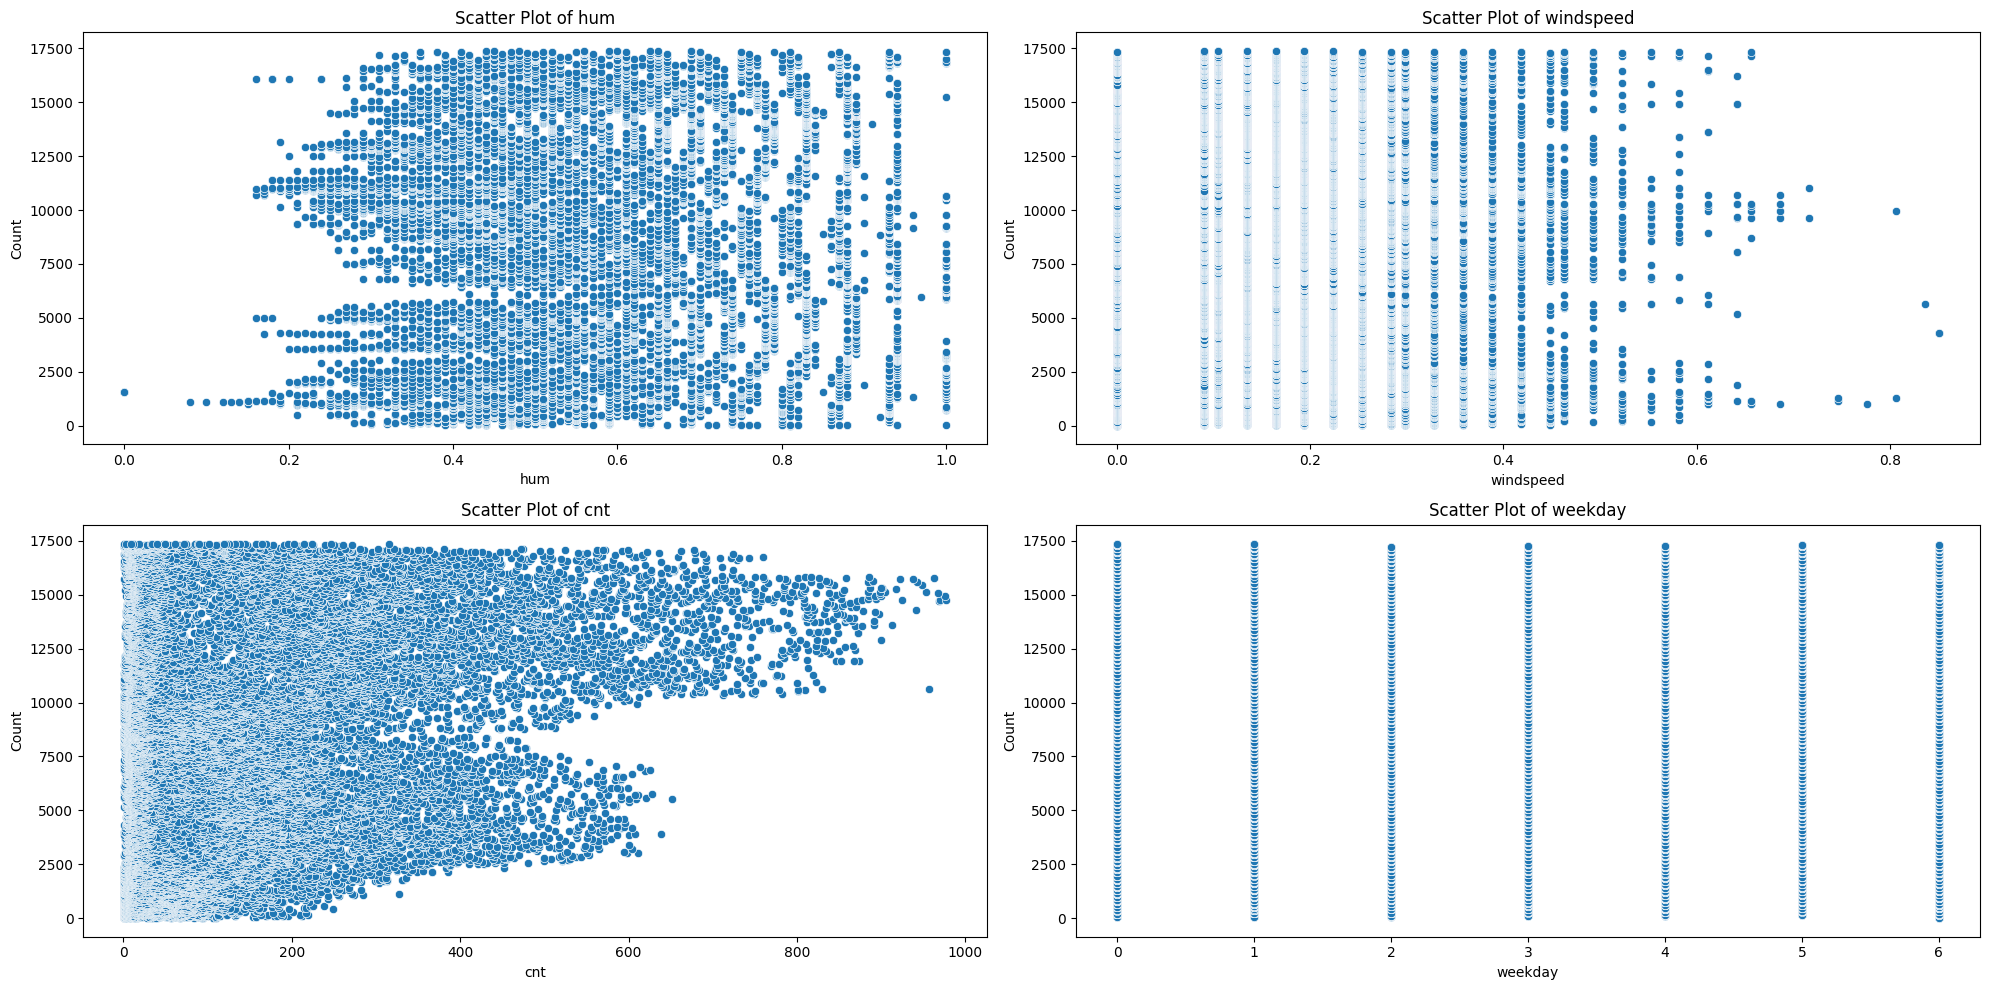

In [851]:
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
for variable, subplot in zip(data_numerical.columns, ax.flatten()):
    sns.scatterplot(x=data_numerical[variable], y=data_numerical.index, ax=subplot)
    subplot.set_ylabel("Count")
    subplot.set_title(f"Scatter Plot of {variable}")

plt.tight_layout()
plt.show()

**Завдання 10** побудуйте гістограму розподілу цільової змінної та розрахуйте коефіціент нахилу

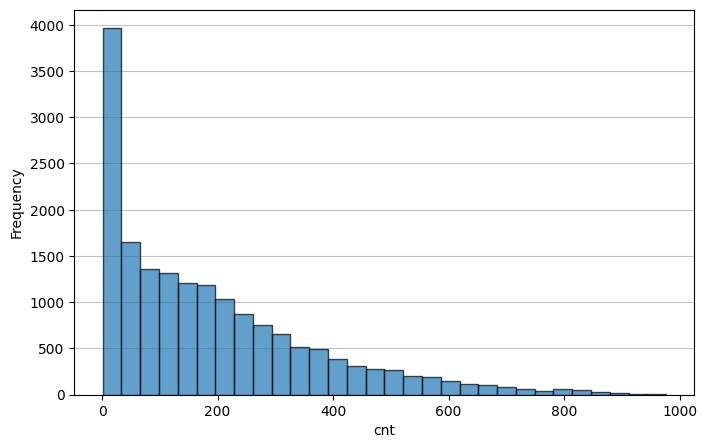

In [852]:
plt.figure(figsize=(8, 5))
plt.hist(df['cnt'], bins=30, edgecolor='black', alpha=0.7, zorder=4)
plt.xlabel('cnt')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.show()



In [853]:
skewness = sc.stats.skew(df['cnt'])
skewness

np.float64(1.2773013463494975)

**Висновки з 8-10 завдання (детальні)**


1. The skewness coefficient is 1.28.
2. Most likely, the number of calls is between 0 and 200.
3. There are no linear dependencies.
4. Higher number of calls can be found more frequently then lower


#Аналіз взаємозв'язків між числовими і категоріальними змінними

**Завдання 11** побудуйте графіки співвідношення `scatterplot` між всіма числовими змінними і цільовою змінною `cnt`

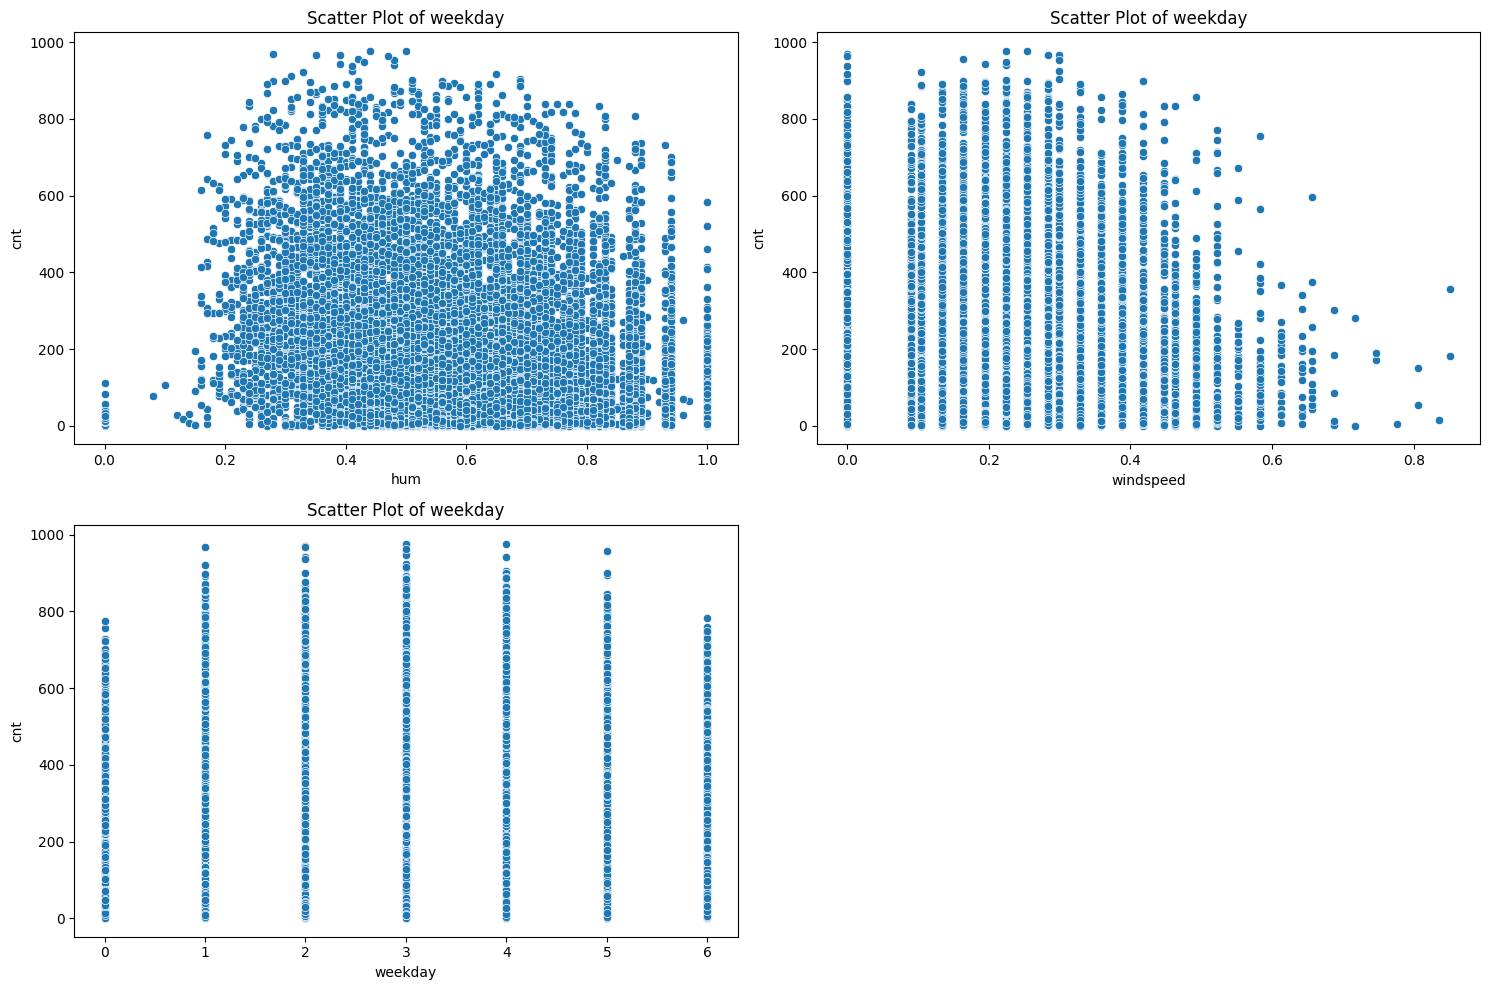

In [854]:
fig, ax = plt.subplots(2,2, figsize=(15, 10))
for var, subplot in zip(data_numerical.drop('cnt', axis =1), ax.flatten()):
    sns.scatterplot(data=data_numerical, x=var, y="cnt", ax=subplot)
    subplot.set_ylabel("cnt")
    subplot.set_title(f"Scatter Plot of {variable}")

for extra_subplot in ax.flatten()[len(data_numerical.columns) - 1:]:
    fig.delaxes(extra_subplot)

plt.tight_layout()
plt.show()

**Завдання 12** побудуйте графіки співвідношення `boxplot`[boxplot](https://matplotlib.org/stable/gallery/statistics/boxplot_demo.html) між категоріальними змінними і цільовою змінною `cnt`.

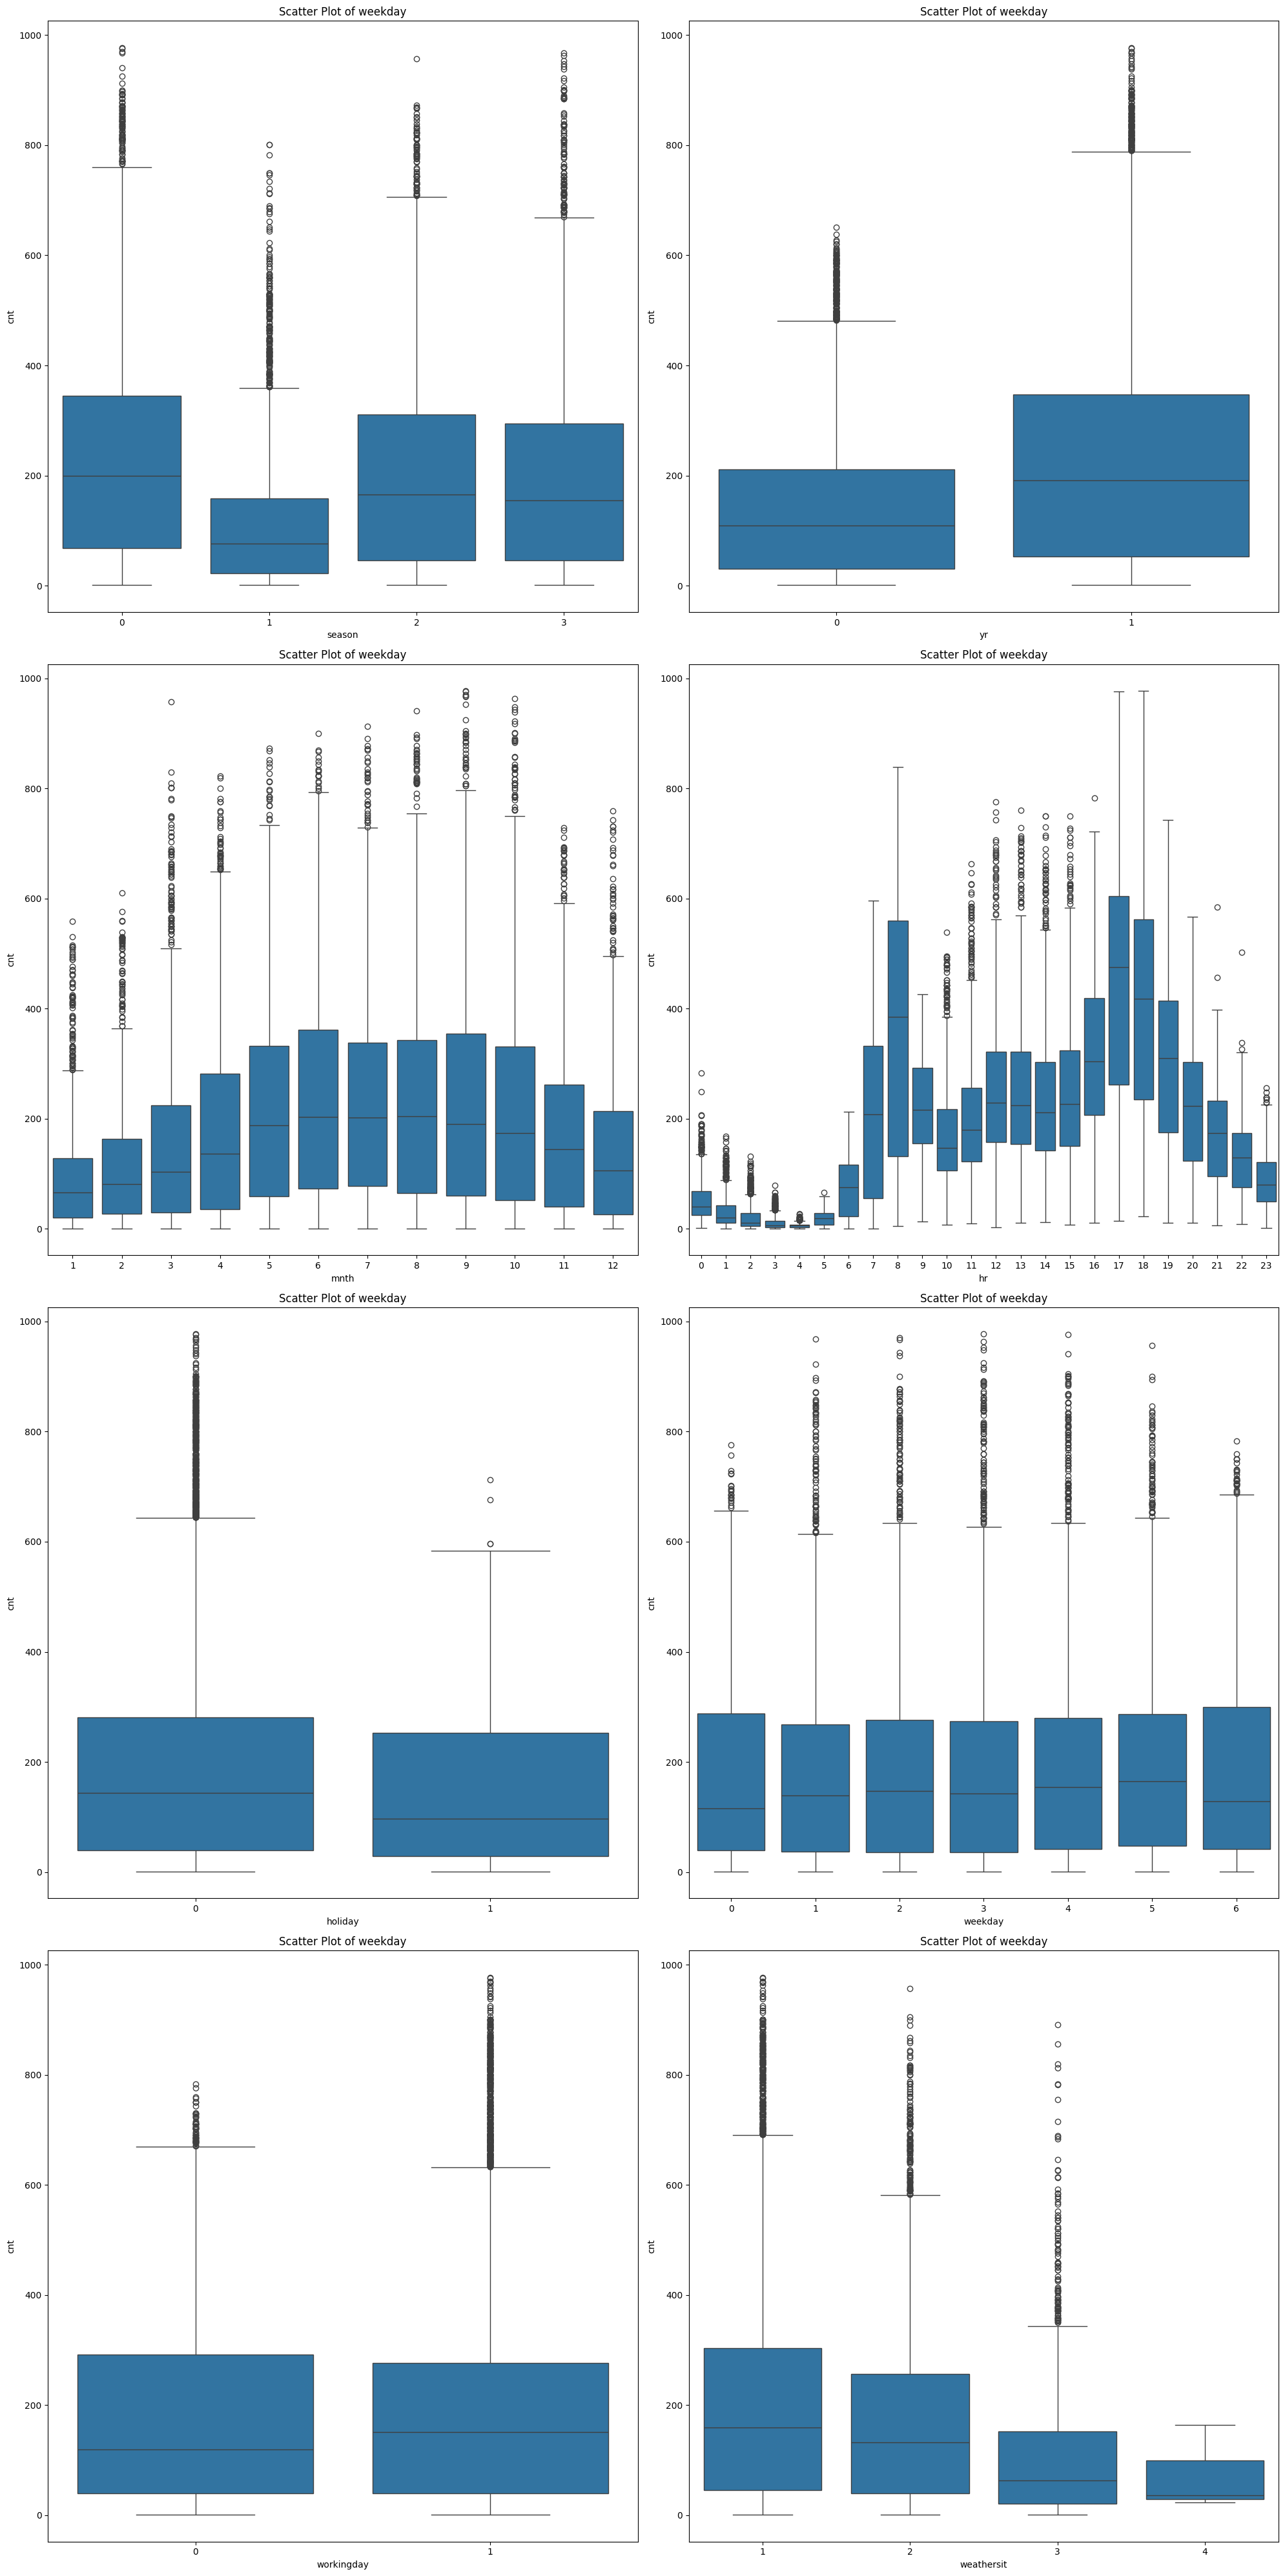

In [855]:
df_categorical = df[["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit", "cnt"]].copy()
df_categorical = encode_season(df_categorical)

fig, ax = plt.subplots(4, 2, figsize=(20, 40))
for var, subplot in zip(df_categorical.drop('cnt', axis =1), ax.flatten()):
    sns.boxplot(data=df_categorical, x=var, y="cnt", ax=subplot)
    subplot.set_title(f"Scatter Plot of {variable}")

plt.tight_layout()
plt.show()

**Висновки з 11-12 завдання (детальні)**

1. There are many irregularities in the data.
2. Strong wind speeds were recorded very infrequently.
3. The highest number of emergency calls happens at 8 AM and between 5-6 PM. This likely reflects morning and evening rush hours, leading to traffic jams and accidents.
4. Accidents are less frequent in summer, probably due to better weather conditions.
5. The number of accidents was higher in 2012.


**Завдання 13** Побудувати матрицю кореляції:  

1.   Вирахувати кореляційні коефіціенти для набору данних за методом Пірсона
2.   Відобразити отриману матрицю коефіціентів у вигляді теплокарти  
3.   Вирахувати кореляційні коефіціенти для набору данних за методом Спірмана
4.   Відобразити отриману матрицю коефіціентів у вигляді теплокарти

5. Описати отримані результати, спираючись на значення коефіціентів кореляції та пояснити в чому відмінність обраних методів.

In [856]:
correlation_matrix_pearson = data_numerical.corr(method='pearson')
correlation_matrix_spearman = data_numerical.corr(method='spearman')

(correlation_matrix_pearson, correlation_matrix_spearman)

(                hum  windspeed       cnt   weekday
 hum        1.000000  -0.290105 -0.322911 -0.037158
 windspeed -0.290105   1.000000  0.093234  0.011502
 cnt       -0.322911   0.093234  1.000000  0.026900
 weekday   -0.037158   0.011502  0.026900  1.000000,
                 hum  windspeed       cnt   weekday
 hum        1.000000  -0.293913 -0.359614 -0.036598
 windspeed -0.293913   1.000000  0.126629  0.009936
 cnt       -0.359614   0.126629  1.000000  0.030297
 weekday   -0.036598   0.009936  0.030297  1.000000)

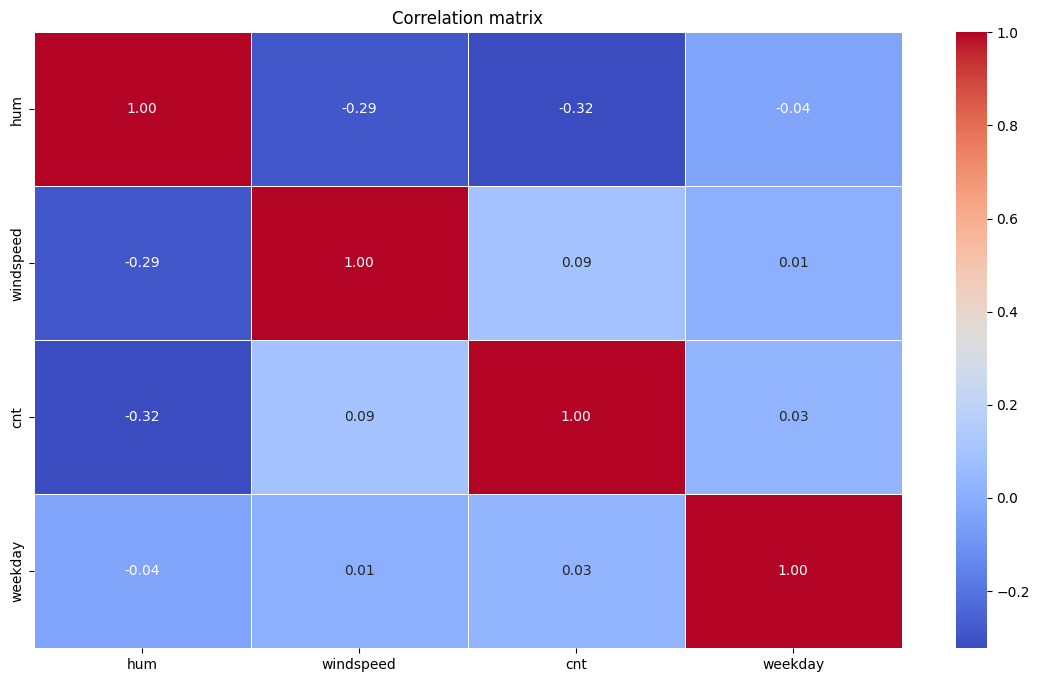

In [857]:
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix_pearson, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix")
plt.show()

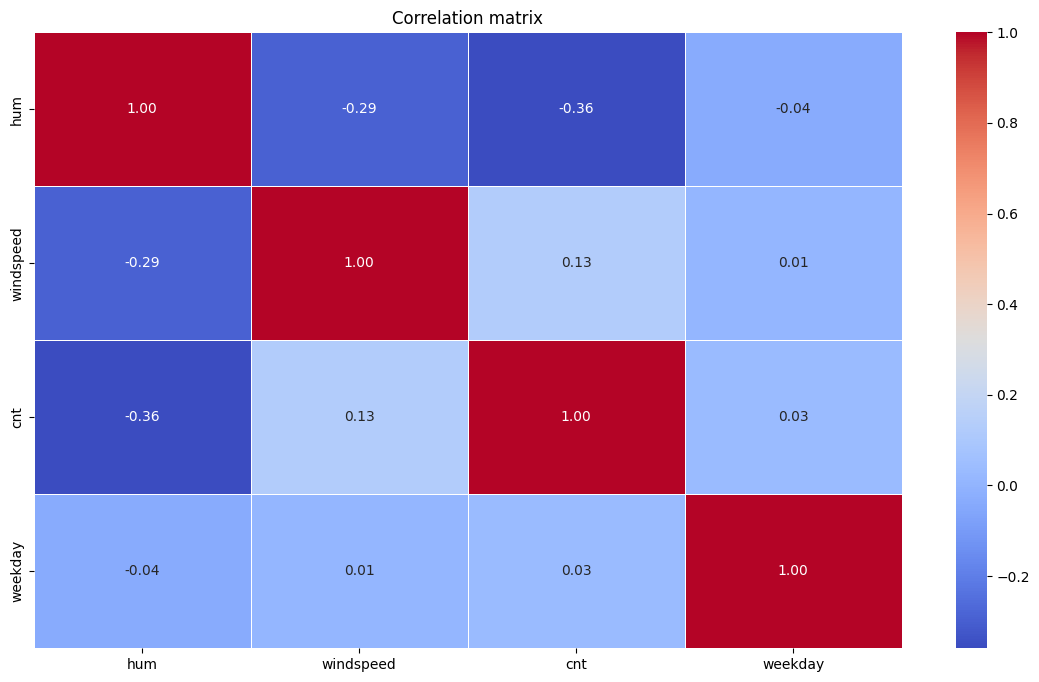

In [858]:
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix_spearman, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix")
plt.show()

There is no obvious linear dependencies

**Завдання 14** 
1. побудувати модель лінійної регресії:
2. видалити змінні, які НЕ є релевантними;

3. поділити вибірку на `train`, `test` та `validation` в пропорції `70/30`;  

4. провести навчання моделі лінійної регресії;

1. Для подальшої роботи з моделями для кожної категоріальної змінної ми створимо фіктивні змінні, щоб уникнути неправильного порядку категорій. [get_dummies](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)

In [860]:
def get_dummies(df: pd.DataFrame):
    features = pd.concat([
        df,
        pd.get_dummies(df['season']),
        pd.get_dummies(df['mnth'], prefix='mnth'),
        pd.get_dummies(df['hr'], prefix='hr'),
        pd.get_dummies(df['weekday'], prefix='weekday'),
        pd.get_dummies(df['weathersit'], prefix='weathersit')
    ], axis=1)
    
    features = features.drop(['season', 'mnth', 'weekday', 'weathersit'], axis=1)
    
    return features

In [861]:
features = get_dummies(df)
features.columns

Index(['index', 'date', 'yr', 'hr', 'holiday', 'workingday', 'temp', 'atemp',
       'hum', 'windspeed', 'cnt', 'autumn', 'spring', 'summer', 'winter',
       'mnth_1', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7',
       'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_0', 'hr_1',
       'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10',
       'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18',
       'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'weekday_0', 'weekday_1',
       'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6',
       'weathersit_1', 'weathersit_2', 'weathersit_3', 'weathersit_4'],
      dtype='object')

2. На основі змінної часу створіть нову змінну, яка відповідатиме за день і ніч.

In [862]:
features['night_hours'] = (features['hr'] < 6) | (features['hr'] >= 23)
features['night_hours'] = features['night_hours'].astype(int)

features = features.drop('hr', axis = 1)
features

,index,date,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,...,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_1,weathersit_2,weathersit_3,weathersit_4,night_hours
0,1,2011-01-01,0,0,0,0.24,0.2879,0.81,0.0000,16,...,False,False,False,False,True,True,False,False,False,1
1,2,2011-01-01,0,0,0,0.22,0.2727,0.80,0.0000,40,...,False,False,False,False,True,True,False,False,False,1
2,3,2011-01-01,0,0,0,0.22,0.2727,0.80,0.0000,32,...,False,False,False,False,True,True,False,False,False,1
3,4,2011-01-01,0,0,0,0.24,0.2879,0.75,0.0000,13,...,False,False,False,False,True,True,False,False,False,1
4,5,2011-01-01,0,0,0,0.24,0.2879,0.75,0.0000,1,...,False,False,False,False,True,True,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,0,1,0.26,0.2576,0.60,0.1642,119,...,False,False,False,False,False,False,True,False,False,0
17375,17376,2012-12-31,1,0,1,0.26,0.2576,0.60,0.1642,89,...,False,False,False,False,False,False,True,False,False,0
17376,17377,2012-12-31,1,0,1,0.26,0.2576,0.60,0.1642,90,...,False,False,False,False,False,True,False,False,False,0
17377,17378,2012-12-31,1,0,1,0.26,0.2727,0.56,0.1343,61,...,False,False,False,False,False,True,False,False,False,0


**Модель лінійної регрессії  

[train_linear_model](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

Після отримання фіктивних змінних потрібно видалити по одній з кожної категорії, щоб запобігти мультиколінеарності. Також видаляємо ще два атрибути `date` та `atemp` - поясніть чому?

In [863]:
features_lr = features.drop(['spring', 'mnth_4', 'weekday_0', 'weathersit_1', 'hr_0','atemp', 'date'], axis = 1)

In [864]:
def get_train_data(df: pd.DataFrame, target: str, test_size: float):
    X = df.drop(columns=[target])  
    y = df[target]  
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, shuffle=True
    )
    
    return X_train, X_test, y_train, y_test

In [865]:
X_train, X_test, y_train, y_test = get_train_data(features_lr, 'cnt', 0.3)

In [866]:
def train_linear_model(X_train, y_train):
  model = LinearRegression()
  model.fit(X_train, y_train)
  return model

model = train_linear_model(X_train, y_train)

In [867]:
# predict
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
# scores
print('MSE train: {:.3f}, test: {:.3f}'.format(
        mean_squared_error(y_train, y_train_pred),
        mean_squared_error(y_test, y_test_pred)))
print('R^2 train: {:.3f}, test: {:.3f}'.format(
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_test_pred)))

MSE train: 10448.098, test: 10101.710
R^2 train: 0.688, test: 0.680


Оскільки в нашій моделі є багато незалежних змінних, ми не можемо відобразити їх залежність у двовимірному просторі, але ми можемо побудувати графік взаємозв'язку між залишками моделі та передбачуваними значеннями, що також допоможе нам оцінити якість моделі.

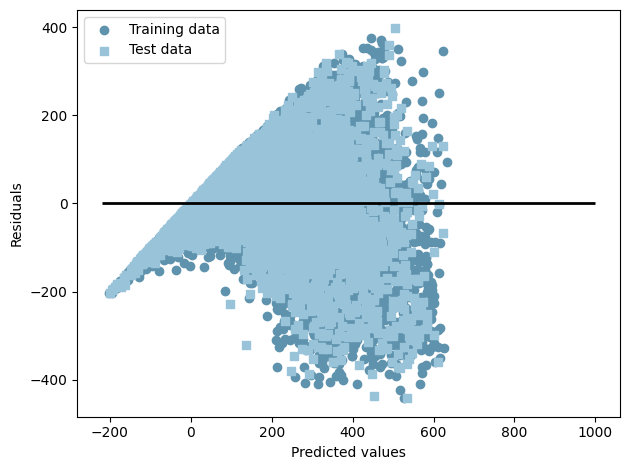

In [868]:
plt.scatter(y_train_pred,  y_train_pred - y_train,
            c='#5f93ad', marker='o', label='Training data')
plt.scatter(y_test_pred,  y_test_pred - y_test,
            c='#98c3d9', marker='s', label='Test data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.legend(loc='upper left')
plt.hlines(y=0, xmin=-220, xmax=1000, lw=2, color='#000000')
plt.tight_layout()

**Висновки з завдання (детальні)**

1.   You dropped highly correlated or unnecessary features to simplify the model and reduce multicollinearity.
2.   MSE indicates prediction accuracy, and R² shows how well the model explains the variance in the target. High R² and low MSE suggest good model performance.
3.   f MSE is low and R² is high, the model is performing well. Residuals plot suggests no major issues with the model.